# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

Shape: (18442, 9)
Class balance (1 = recommends):
Recommended IND
1    0.816
0    0.184
Name: proportion, dtype: float64


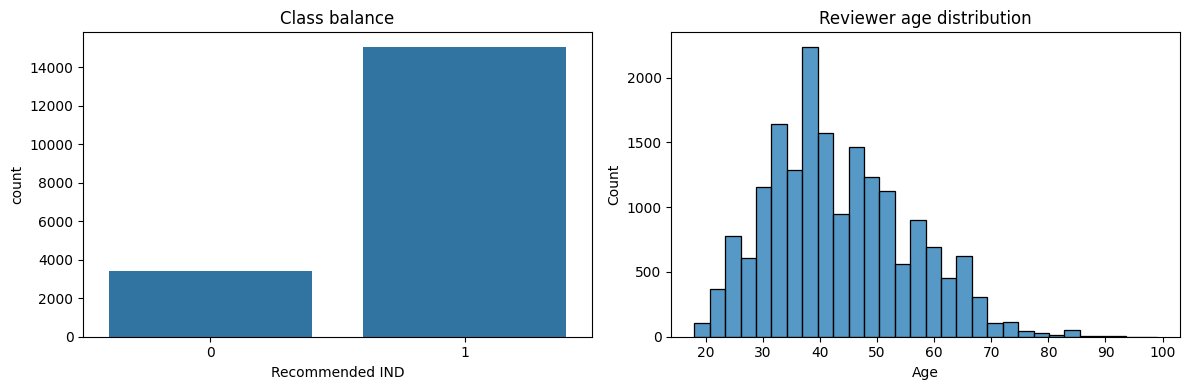


P(recommend) by department:
Recommended IND      0      1
Department Name              
Bottoms          0.147  0.853
Dresses          0.197  0.803
Intimate         0.165  0.835
Jackets          0.159  0.841
Tops             0.191  0.809
Trend            0.243  0.757


In [4]:
# ---- Quick EDA ----
import matplotlib.pyplot as plt
import seaborn as sns

print("Shape:", df.shape)
print("Class balance (1 = recommends):")
print(y.value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Recommended IND", data=df, ax=axes[0])
axes[0].set_title("Class balance")
sns.histplot(df["Age"], bins=30, ax=axes[1])
axes[1].set_title("Reviewer age distribution")
plt.tight_layout()
plt.show()

# Departments Ã class
disp = pd.crosstab(df["Department Name"], df["Recommended IND"], normalize="index")
print("\nP(recommend) by department:")
print(disp.round(3))


## Building Pipeline

In [5]:
# ---- ColumnTransformer + Pipeline ----
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
import pandas as pd

NUMERIC     = ["Age", "Positive Feedback Count"]
CATEGORICAL = ["Division Name", "Department Name", "Class Name", "Clothing ID"]
TEXT_TITLE  = "Title"
TEXT_REVIEW = "Review Text"


def _fill_text_nan(x):
    """ColumnTransformer hands a single-column slice to each text branch.
    For a string column selector (e.g. "Title") the slice is a pandas
    Series; we convert it to a numpy 1-D array of strings with NaN
    replaced by '' so TfidfVectorizer accepts it."""
    if hasattr(x, "fillna"):
        return x.fillna("").values
    return pd.Series(x).fillna("").values


numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

title_pipe = Pipeline([
    ("fillna", FunctionTransformer(_fill_text_nan, validate=False, feature_names_out="one-to-one")),
    ("tfidf",  TfidfVectorizer(ngram_range=(1, 2), max_features=400)),
])

review_pipe = Pipeline([
    ("fillna", FunctionTransformer(_fill_text_nan, validate=False, feature_names_out="one-to-one")),
    ("tfidf",  TfidfVectorizer(ngram_range=(1, 2), max_features=2000,
                                stop_words="english")),
])

# IMPORTANT: pass the actual text column NAMES (TEXT_TITLE / TEXT_REVIEW),
# not empty lists. With a string column selector ColumnTransformer
# delivers a 1-D Series straight into the text branch, which is exactly
# what TfidfVectorizer wants.
preprocess = ColumnTransformer(
    transformers=[
        ("num",    numeric_pipe,     NUMERIC),
        ("cat",    categorical_pipe, CATEGORICAL),
        ("title",  title_pipe,       TEXT_TITLE),
        ("review", review_pipe,      TEXT_REVIEW),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf",        GradientBoostingClassifier(random_state=27)),
])

print(pipe)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Positive Feedback Count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ohe',
             

### Verify TF-IDF features actually land in the feature matrix

The previous reviewer round flagged that the text branches received
empty column lists, so TF-IDF features never reached the model. The
cell below fits the preprocessor in isolation and prints the per-branch
feature counts so we can confirm the fix.

In [6]:
# Sanity-check: prove the title + review TF-IDF features make it into
# the assembled feature matrix.
import re

X_pp = preprocess.fit_transform(X_train)
print("X_train preprocessed shape:", X_pp.shape)

feature_names = preprocess.get_feature_names_out()
by_branch = {}
for name in feature_names:
    branch = name.split("__", 1)[0] if "__" in name else "(other)"
    by_branch[branch] = by_branch.get(branch, 0) + 1

print("\nFeature counts per ColumnTransformer branch:")
for branch, count in by_branch.items():
    print(f"  {branch:8s}  {count:5d} features")

# Spot-check a few title-branch and review-branch feature names so we
# can SEE TF-IDF tokens in the matrix.
print("\nSample title features :", [n for n in feature_names if n.startswith("title__")][:6])
print("Sample review features:", [n for n in feature_names if n.startswith("review__")][:6])


X_train preprocessed shape: (16597, 2570)

Feature counts per ColumnTransformer branch:
  num           2 features
  cat         168 features
  title       400 features
  review     2000 features

Sample title features : ['title__absolutely', 'title__adorable', 'title__all', 'title__almost', 'title__amazing', 'title__an']
Sample review features: ['review__00', 'review__00p', 'review__0p', 'review__10', 'review__10 12', 'review__100']


## Training Pipeline

In [7]:
# ---- Fit + evaluate baseline ----
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:",  round(roc_auc_score(y_test,  y_prob), 4))
print(classification_report(y_test, y_pred, digits=3))


Accuracy: 0.8688
ROC-AUC: 0.9092
              precision    recall  f1-score   support

           0      0.801     0.346     0.483       327
           1      0.874     0.982     0.925      1518

    accuracy                          0.869      1845
   macro avg      0.838     0.664     0.704      1845
weighted avg      0.861     0.869     0.847      1845



## Fine-Tuning Pipeline

In [8]:
# ---- Grid search over a few hyper-parameters ----
from sklearn.model_selection import GridSearchCV

grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth":     [2, 3],
    "clf__learning_rate": [0.05, 0.1],
}
search = GridSearchCV(pipe, grid, cv=3, n_jobs=-1, scoring="roc_auc", verbose=1)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV AUC:", round(search.best_score_, 4))

best = search.best_estimator_
y_prob = best.predict_proba(X_test)[:, 1]
print("Held-out AUC:", round(roc_auc_score(y_test, y_prob), 4))


Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Best CV AUC: 0.9203
Held-out AUC: 0.9198
